# Example of using C++ code in python and Jupyter with SWIG

It is also possible to use our C++ code from python and Jupyter. This involves using the [SWIG](http://www.swig.org) package. You can download it [here](http://www.swig.org/survey.html) and then install following instructions [here](http://www.swig.org/Doc3.0/Preface.html#Preface_installation). If you are successful, you should be able to open a new terminal and type ```which swig``` to obtain the path of swig. 

The idea is then to use SWIG to automatically generate python-readable code from our C++/C libraries. There is a lot to learn in this regard, so we will try first with a simple example that illustrates some concepts we will need, such as using STL libraries and C++11 compilation. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba



## Step 1 : Look at C++ files

You should be able to see these two simple C++ files: 


In [2]:
! cat swig_example/example.h swig_example/example.cpp 

#ifndef EXAMPLE_H
#define EXAMPLE_H

#include <vector>

// Declare your function normally
int sum_int(std::vector<int> const & vec);

#endif // EXAMPLE_H
#include "example.h"

// Define your function as you need.
int sum_int(std::vector<int> const & vec)
{
  int sum = 0;
  for ( auto i : vec ) {
    sum += i;
  }
  return sum;
}




## Step 2 : Look at SWIG interface file

The magic of SWIG is to create wrapper C++ functions that use the "cython" interface. You will see an "interface" file for SWIG :

In [3]:
! cat swig_example/example.i 

%module example_swig
/* First: Include your own code.*/
%{
#define SWIG_FILE_WITH_INIT
#include "example.h"
%}
/* Next: declare the functions you want to use.*/
int sum_int(std::vector<int> const & vec);

/* Finally: include any other libraries and types you need. 
Yes, you need one type per class, so that means one type per
template instance.*/


%include "std_vector.i"

namespace std {
   %template(vector_int) vector<int>;
};




## Step 3 : Look at SWIG setup file

This tells SWIG to generate a file called ```example_wrap.cc``` using source from ```example.cpp``` with C++11. 


In [4]:
! cat swig_example/setup.py

#!/usr/bin/env python

"""
setup.py file for SWIG example
"""

from distutils.core import setup, Extension


example_module = Extension('_example_swig',
                           sources=['swig_example/example_wrap.cxx', 'swig_example/example.cpp'],
                           extra_compile_args=["-std=c++11"],
                           )

setup (name = 'example_swig',
       version = '0.1',
       author      = "SWIG Docs",
       description = """Simple swig example from docs""",
       ext_modules = [example_module],
       py_modules = ["example"],
       )


Now create the interface using the interface file. This will create two files, ```example_wrap.cxx``` and ```example.py```. They are not intended to be human-readable, so we don't need to look into them. 

## Step 4: Create SWIG interface from file

In [5]:
! swig -c++ -python swig_example/example.i 

## Step 5 : compile C++ and interface

This will compile our file ```example.cpp``` along with ```example_wrap.cxx``` using the rules we set (for instance, using the C++11 compiler). 

We are now free to use this in python!

In [6]:
! python swig_example/setup.py build_ext --inplace

ld: warning: duplicate -rpath '/Users/dryu/Documents/Buffalo/PHY410/student/CompPhys/.pixi/envs/default/lib' ignored



## Step 6: Make profit: 

First we import the path correctly. 

In [7]:
import sys
import os

sys.path.append( os.path.abspath("swig_example") )

print (sys.path)




['/Users/dryu/Documents/Buffalo/PHY410/student/CompPhys/.pixi/envs/default/lib/python313.zip', '/Users/dryu/Documents/Buffalo/PHY410/student/CompPhys/.pixi/envs/default/lib/python3.13', '/Users/dryu/Documents/Buffalo/PHY410/student/CompPhys/.pixi/envs/default/lib/python3.13/lib-dynload', '', '/Users/dryu/Documents/Buffalo/PHY410/student/CompPhys/.pixi/envs/default/lib/python3.13/site-packages', '/Users/dryu/Documents/Buffalo/PHY410/student/CompPhys/SwigExamples/swig_example']


Next we import our actual function from "example.py"

In [9]:
import example_swig
help(example_swig)

Help on module example_swig:

NAME
    example_swig

DESCRIPTION
    # This file was automatically generated by SWIG (https://www.swig.org).
    # Version 4.5.0
    #
    # Do not make changes to this file unless you know what you are doing - modify
    # the SWIG interface file instead.

CLASSES
    builtins.object
        SwigPyIterator
        vector_int

    class SwigPyIterator(builtins.object)
     |  SwigPyIterator(*args, **kwargs)
     |
     |  Methods defined here:
     |
     |  __add__(self, n)
     |
     |  __eq__(self, x)
     |      Return self==value.
     |
     |  __iadd__(self, n)
     |
     |  __init__(self, *args, **kwargs)
     |      Initialize self.  See help(type(self)) for accurate signature.
     |
     |  __isub__(self, n)
     |
     |  __iter__(self)
     |
     |  __ne__(self, x)
     |      Return self!=value.
     |
     |  __next__(self)
     |
     |  __repr__ = _swig_repr(self)
     |
     |  __sub__(self, *args)
     |
     |  advance(self, n)
   

And finally, we can use our code: 

In [10]:
a = example_swig.vector_int([1,2,3])
x = example_swig.sum_int(a)
print (x)


6


# Success!
Now let's compare with bare python, numba, and numpy.

In [11]:
import numba
import numpy as np

def sum_int_py(arr):
    total = 0
    for x in arr:
        total += x
    return total

@numba.jit(nopython=True)
def sum_int_numba(arr):
    total = 0
    for x in arr:
        total += x
    return total
sum_int_py([0, 1, 2, 3]) # Run it once to force compilation

6

In [12]:
arr_np = np.arange(1_000_000)
print("Bare python:")
%timeit sum_int_py(arr_np)

print("numpy built-in:")
%timeit np.sum(arr_np)

print("numba:")
%timeit sum_int_numba(arr_np)

arr_cpp = example_swig.vector_int(range(1000000))
print("swig:")
%timeit example_swig.sum_int(arr_cpp)

Bare python:
32.5 ms ± 1.21 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
numpy built-in:
76.1 μs ± 1.18 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
numba:
347 μs ± 6.64 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
swig:
36.1 μs ± 281 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [13]:
# Finally, map out the performance to inspect the overhead
xx = np.array([10**i for i in range(8)])
t_py = np.zeros_like(xx, dtype=float)
dt_py = np.zeros_like(xx, dtype=float)
t_numba = np.zeros_like(xx, dtype=float)
dt_numba = np.zeros_like(xx, dtype=float)
t_numpy = np.zeros_like(xx, dtype=float)
dt_numpy = np.zeros_like(xx, dtype=float)
t_swig = np.zeros_like(xx, dtype=float)
dt_swig = np.zeros_like(xx, dtype=float)

for i in range(len(xx)):
    print(f"Test length {xx[i]}")
    print("Bare python")
    arr_np = np.arange(xx[i])
    result_py = %timeit -o sum_int_py(arr_np)
    t_py[i] = result_py.average
    dt_py[i] = result_py.stdev

    print("Numba")
    result_numba = %timeit -o sum_int_numba(arr_np)
    t_numba[i] = result_numba.average
    dt_numba[i] = result_numba.stdev

    print("Numpy")
    result_numpy = %timeit -o np.sum(arr_np)
    t_numpy[i] = result_numpy.average
    dt_numpy[i] = result_numpy.stdev

    print("Swig")
    arr_cpp = example_swig.vector_int(range(xx[i]))
    result_swig = %timeit -o example_swig.sum_int(arr_cpp)
    t_swig[i] = result_swig.average
    dt_swig[i] = result_swig.stdev


Test length 1
Bare python
239 ns ± 4.58 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Numba
62.1 ns ± 1.74 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
Numpy
638 ns ± 7.7 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Swig
76.2 ns ± 1.8 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
Test length 10
Bare python
571 ns ± 2.94 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Numba
62.9 ns ± 0.448 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
Numpy
596 ns ± 1.03 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Swig
76.3 ns ± 1.45 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
Test length 100
Bare python
3.55 μs ± 24.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Numba
91.2 ns ± 0.649 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
Numpy
604 ns ± 2.76 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Swig
81.6 ns ± 2.

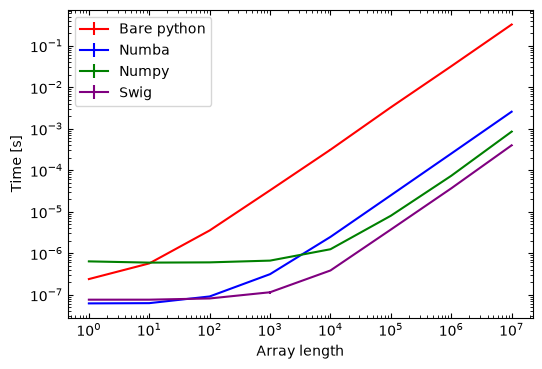

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(xx, t_py, yerr=dt_py, color="red", label="Bare python")
ax.errorbar(xx, t_numba, yerr=dt_numba, color="blue", label="Numba")
ax.errorbar(xx, t_numpy, yerr=dt_numpy, color="green", label="Numpy")
ax.errorbar(xx, t_swig, yerr=dt_swig, color="purple", label="Swig")
ax.set_xlabel("Array length")
ax.set_xscale("log")
ax.set_ylabel("Time [s]")
ax.set_yscale("log")
ax.tick_params(which='both', direction="in", top=True, bottom=True, left=True, right=True)
ax.legend(loc="upper left")
fig.savefig("perf_swig.svg")